In [66]:
# Libraries

In [137]:
import numpy as np
import pandas as pd
import seaborn as sns
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import pickle

# Dataset

In [68]:
df_true = pd.read_csv('/content/drive/MyDrive/Fake_and_Real_news _detection/Data/fake_Real/True.csv')
df_fake = pd.read_csv("/content/drive/MyDrive/Fake_and_Real_news _detection/Data/fake_Real/Fake.csv")

In [69]:
df_true

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [70]:
df_fake

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


# EDA

In [71]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [72]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [73]:
df_true.shape

(21417, 4)

In [74]:
df_fake.shape

(23481, 4)

## checking missing values

In [75]:
df_true.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [76]:
df_fake.isnull().sum()

,0
title,0
text,0
subject,0
date,0


## Checking duplicates

In [77]:
df_true.duplicated().sum()

np.int64(206)

In [78]:
df_true["label"] = 1
df_fake["label"] = 0

In [79]:
print(df_true["label"].value_counts())
print(df_fake["label"].value_counts())

label
1    21417
Name: count, dtype: int64
label
0    23481
Name: count, dtype: int64


##Article length

In [80]:
df_true["word_count"] = df_true["text"].apply(lambda x: len(str(x).split()))
df_true["char_count"] = df_true["text"].apply(lambda x: len(str(x)))
print(df_true["word_count"].describe())

count    21417.000000
mean       385.640099
std        274.006204
min          0.000000
25%        148.000000
50%        359.000000
75%        525.000000
max       5172.000000
Name: word_count, dtype: float64


In [81]:
df_fake["word_count"] = df_fake["text"].apply(lambda x: len(str(x).split()))
df_fake["char_count"] = df_fake["text"].apply(lambda x: len(str(x)))
print(df_fake["word_count"].describe())

count    23481.000000
mean       423.197905
std        408.388890
min          0.000000
25%        240.000000
50%        363.000000
75%        506.000000
max       8135.000000
Name: word_count, dtype: float64


Do fake and real articles differ significantly in length?

yes the there is a length differentiation between fake and real articles

##Vocabulary size

In [82]:
true_text = " ".join(df_true["text"].astype(str))
true_words = re.findall(r"\b[a-zA-Z]+\b", true_text.lower())
true_vocabulary = set(true_words)
true_vocabulary_size = len(true_vocabulary)
print("Vocabulary size of Real news:", true_vocabulary_size)

Vocabulary size of Real news: 63251


In [83]:
fake_text = " ".join(df_fake["text"].astype(str))
fake_words = re.findall(r"\b[a-zA-Z]+\b", fake_text.lower())
fake_vocabulary = set(fake_words)
fake_vocabulary_size = len(fake_vocabulary)
print("Vocabulary size of Fake news:", fake_vocabulary_size)

Vocabulary size of Fake news: 79654


what challenges do noisy textual datasets introduce?


why is class balance important in fake news detection?

because it will affect the model traning

#Preprocessing

In [84]:
df_news = pd.concat([df_true, df_fake]).reset_index(drop=True)

In [85]:
df_news.head()

,title,text,subject,date,label,word_count,char_count
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1,749,4659
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1,624,4077
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1,457,2789
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1,376,2461
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1,852,5204


In [86]:
df_news.duplicated().sum()

np.int64(209)

In [87]:
def clean_text(text):
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [88]:
df_news['title'] = df_news['title'].apply(clean_text)
df_news['text'] = df_news['text'].apply(clean_text)

In [89]:
df_news.head()

,title,text,subject,date,label,word_count,char_count
0,as us budget fight looms republicans flip thei...,washington reuters the head of a conservative ...,politicsNews,"December 31, 2017",1,749,4659
1,us military to accept transgender recruits on ...,washington reuters transgender people will be ...,politicsNews,"December 29, 2017",1,624,4077
2,senior us republican senator let mr mueller do...,washington reuters the special counsel investi...,politicsNews,"December 31, 2017",1,457,2789
3,fbi russia probe helped by australian diplomat...,washington reuters trump campaign adviser geor...,politicsNews,"December 30, 2017",1,376,2461
4,trump wants postal service to charge much more...,seattlewashington reuters president donald tru...,politicsNews,"December 29, 2017",1,852,5204


##numerical text representation

In [90]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [91]:
x = tfidf.fit_transform(df_news["text"])

##Splitting the data

In [93]:
X = x
y = df_news['label']

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    df_news["text"],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [97]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

1. which preprocessing step had the greatest impact on feature quality?
         changing text into lowecse and numerical text representation

2. How does removing stopwords affect
    

#model building

### Logistic reggression

In [102]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)
logistic_pred = logistic_model.predict(X_test_tfidf)

###Naive Bayes

In [103]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

###SVM

In [104]:
# Linear SVM
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

### Performance comparison

In [124]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [accuracy_score(y_test, logistic_pred),
                accuracy_score(y_test, nb_pred),
                accuracy_score(y_test, svm_pred)],

    "Precision": [precision_score(y_test, logistic_pred),
                  precision_score(y_test, nb_pred),
                  precision_score(y_test, svm_pred)],

    "Recall": [recall_score(y_test, logistic_pred),
              recall_score(y_test, nb_pred),
              recall_score(y_test, svm_pred)],

    "F1 Score": [f1_score(y_test, logistic_pred),
                f1_score(y_test, nb_pred),
                f1_score(y_test, svm_pred)],

    "ROC-AUC": [roc_auc_score(y_test, logistic_model.predict_proba(X_test_tfidf)[:, 1]),
                roc_auc_score(y_test, nb_model.predict_proba(X_test_tfidf)[:, 1]),
                roc_auc_score(y_test, svm_model.decision_function(X_test_tfidf))]

})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.990423,0.986781,0.993231,0.989995,0.999171
1,Naive Bayes,0.960022,0.948366,0.968954,0.958550,0.990757
2,Linear SVM,0.996437,0.996265,0.996265,0.996265,0.999915


In [ ]:
with open('model_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("Model results saved to model_results.pkl")

1.Why can accuracy be misleading in fake news detection?

if we dont get the accuracy correct then the prediction will be wrong and we will not be able to detect fake news

2.Which model generalized the best?

Linear svsm model generalized the best because it has best accuracy,precision, recall, fi_score, roc_acurracy_score

3.which evaluation matrixs to prioritiese?

accuracy and recall


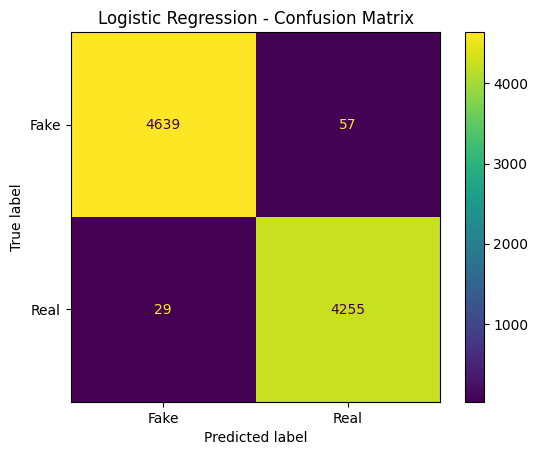

In [126]:
# Logistic Regression

cm_logistic = confusion_matrix(y_test, logistic_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Fake", "Real"]).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


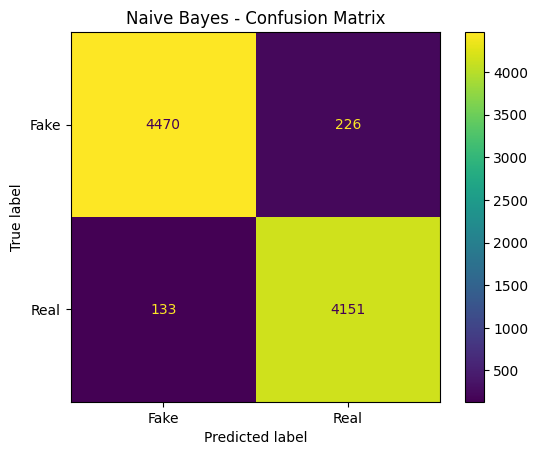

In [128]:
# Naive Bayes

cm_nb = confusion_matrix(y_test, nb_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Fake", "Real"]
).plot()

plt.title("Naive Bayes - Confusion Matrix")
plt.show()

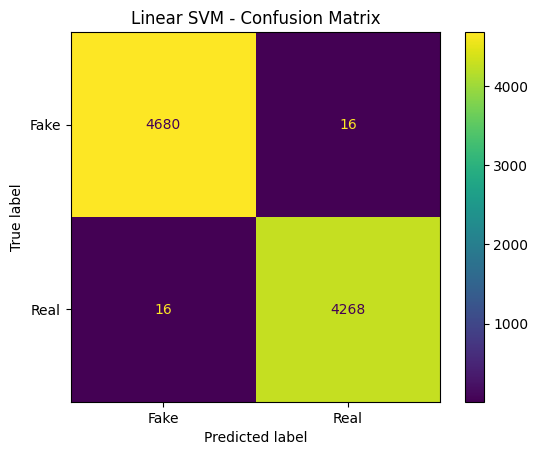

In [131]:
# Linear SVM

cm_svm = confusion_matrix(y_test, svm_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Fake", "Real"]
).plot()

plt.title("Linear SVM - Confusion Matrix")
plt.show()

### misclassified article

In [133]:
error_analysis = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": svm_pred
})

misclassified = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
]

print("Total misclassified articles:", len(misclassified))

Total misclassified articles: 32


In [134]:
for i, row in misclassified.head(15).iterrows():
    print("=" * 100)
    print("Article:", i)
    print("Actual:", "Real" if row["actual"] == 1 else "Fake")
    print("Predicted:", "Real" if row["predicted"] == 1 else "Fake")
    print("\nText:")
    print(row["text"][:1000])
    print()

Article: 34933
Actual: Fake
Predicted: Real

Text:
this could be yuge news for conservatives who were on the fence about trumpgov mike pence is dropping his reelection bid in indiana to become donald trump s running mateindystar has confirmed that trump plans to announce pence as his selection for vice president ending a weekslong vice presidential casting call during which trump vetted a handful of highprofile republicanstrump s national campaign spokeswoman hope hicks said a decision has not been made a formal announcement is scheduled for am friday in manhattanthe longawaited decision upends the political landscape in indiana and at least partially remakes the trump campaign in pence s imagein pence trump has added a social conservative who gop strategists say will reassure rankandfile republicans that trump can be trusted to pursue their interests veteran political observers say pence a former us house member and chairman of the house republican conference will provide a discipline

### Infuventional words

In [135]:
feature_names = tfidf.get_feature_names_out()
coefficients = logistic_model.coef_[0]

feature_importance = pd.DataFrame({"word": feature_names,
    "coefficient": coefficients})

fake_features = feature_importance.sort_values("coefficient").head(20)

real_features = feature_importance.sort_values("coefficient",ascending=False).head(20)

print("Top features for Fake:")
print(fake_features)

print("\nTop features for Real:")
print(real_features)

Top features for Fake:
                  word  coefficient
46547              via    -6.192385
42854             this    -5.491281
27468            obama    -4.987968
39533             that    -4.713613
21165               is    -4.681437
49799              you    -4.305100
22436             just    -4.071055
32912               re    -3.831545
1539           america    -3.826328
31725  president trump    -3.702911
18389          hillary    -3.673973
19488            image    -3.482585
26043               mr    -3.347798
48799             wire    -3.306139
16398              gop    -3.268620
45061            trump    -3.124651
19497        image via    -3.041756
12088              don    -2.994818
29612              our    -2.985161
11496             didn    -2.984359

Top features for Real:
                     word  coefficient
34253             reuters    19.509569
35034                said    17.661349
28775                  on     8.678814
45313              trumps     8.152892
47

### Important features

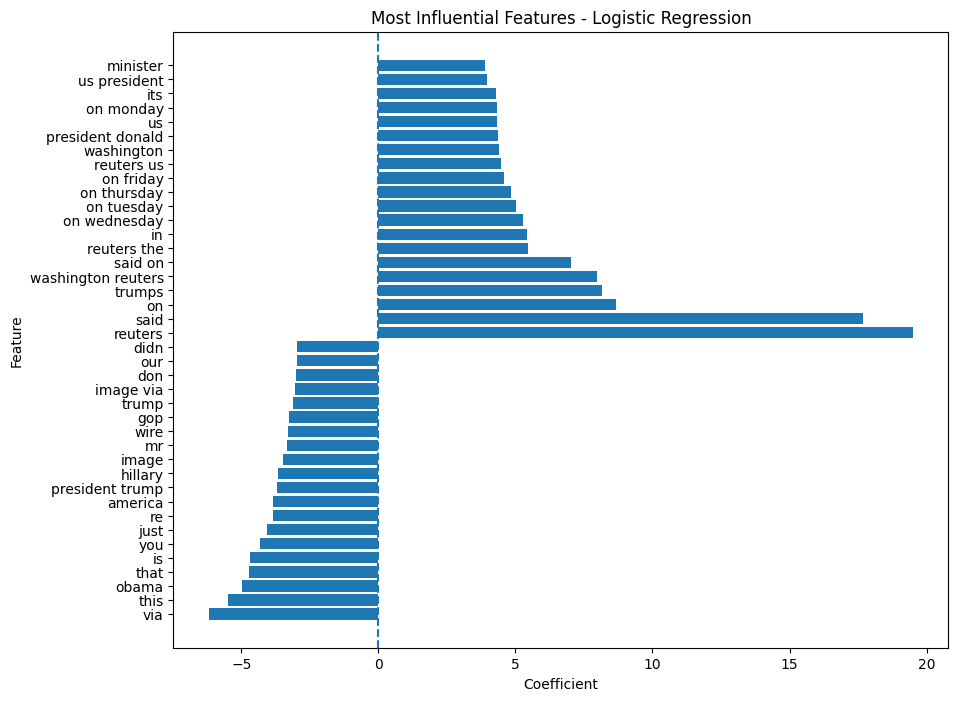

In [138]:
top_features = pd.concat([fake_features,real_features])

plt.figure(figsize=(10, 8))

plt.barh(top_features["word"],
         top_features["coefficient"])

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Most Influential Features - Logistic Regression")
plt.axvline(x=0, linestyle="--")

plt.show()

#pickle file

In [139]:
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

# Saveing trained model
with open("svm_model.pkl", "wb") as file:
    pickle.dump(svm_model, file)

###